In [2]:
import glob
import os
import re

import hapi

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise RuntimeError("matplotlib is required. Install with: pip install matplotlib") from exc

# -------------------------
# USER SETTINGS
# -------------------------
DB_DIR = "hitran_db"
WN_MIN = 2500.0
WN_MAX = 3500.0
WN_STEP = 0.05  # overlaying many species is faster with coarser step
TEMPERATURE_K = 296.0
PRESSURE_ATM = 1.0
OUTPUT_PNG = "all_species_overlay_2500_3500.png"

# -------------------------
# 1) Open local HAPI database
# -------------------------
hapi.db_begin(DB_DIR)

# -------------------------
# 2) Discover hydrocarbon species tables
# -------------------------
header_files = glob.glob(os.path.join(DB_DIR, "*.header"))
name_pat = re.compile(r"^(C\d*H\d*)_M\d+_I1\.header$", re.IGNORECASE)

source_tables = []
for path in header_files:
    fname = os.path.basename(path)
    if name_pat.match(fname):
        source_tables.append(os.path.splitext(fname)[0])

source_tables = sorted(set(source_tables))
if not source_tables:
    raise RuntimeError(
        f"No matching hydrocarbon tables found in '{DB_DIR}'. "
        "Expected files like CH4_M6_I1.header"
    )

print(f"Found {len(source_tables)} species tables")





Using hitran_db

C2H2_M26_I1
                     Lines parsed: 80924
C2H4_M38_I1
                     Lines parsed: 59536
C2H6_M27_I1
                     Lines parsed: 63516
C4H2_M43_I1
                     Lines parsed: 251490
CH3_M57_I1
                     Lines parsed: 342893
CH4_M6_I1
                     Lines parsed: 301838
Found 6 species tables


Computing: C2H2_M26_I1
{'air': 1.0}
24.966622 seconds elapsed for abscoef; nlines = 80924
Computing: C2H4_M38_I1
{'air': 1.0}
24.456668 seconds elapsed for abscoef; nlines = 59536


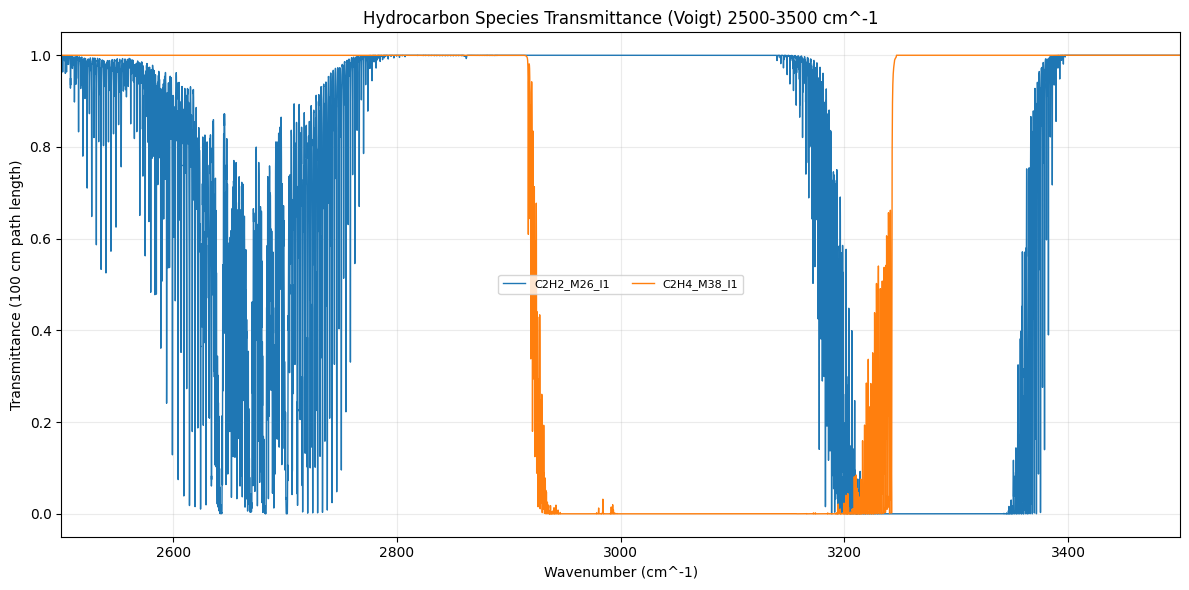

In [7]:
# -------------------------
# 3) Compute one curve per species and overlay
# -------------------------
fig, ax = plt.subplots(figsize=(12, 6))

plotted = 0
for table in source_tables[0:2]:
    print(f"Computing: {table}")
    try:
        nu, coef = hapi.absorptionCoefficient_Voigt(
            SourceTables=[table],
            WavenumberRange=[WN_MIN, WN_MAX],
            WavenumberStep=WN_STEP,
            Environment={"T": TEMPERATURE_K, "p": PRESSURE_ATM},
            HITRAN_units=False, # False cm^-1, True means "HITRAN units" cm^2/molecule
        )
        # only support cm^-1 input coef
        _, trans = hapi.transmittanceSpectrum(
            nu,
            coef,
            Environment={"l": 100.0}  # path length, cm
        )
        ax.plot(nu, trans, lw=1.0, label=table)
        plotted += 1
    except Exception as exc:
        print(f"FAILED {table}: {exc}")

if plotted == 0:
    raise RuntimeError("No species could be plotted. Check your local tables and settings.")

# -------------------------
# 4) Save overlay figure
# -------------------------
# plt.xlim(WN_MIN, WN_MAX)
# plt.xlabel("Wavenumber (cm^-1)")
# plt.ylabel("Absorption coefficient")
# plt.title("Hydrocarbon Species Overlay (Voigt) 2500-3500 cm^-1")
# plt.grid(alpha=0.25)
# plt.legend(fontsize=8, ncol=2)
# plt.tight_layout()
# plt.show()

ax.set_xlim(WN_MIN, WN_MAX)
ax.set_xlabel("Wavenumber (cm^-1)")
ax.set_ylabel("Transmittance (100 cm path length)")
ax.set_title("Hydrocarbon Species Transmittance (Voigt) 2500-3500 cm^-1")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
# plt.savefig(OUTPUT_PNG, dpi=300)

# print(f"Saved plot: {OUTPUT_PNG}")
